<a href="https://colab.research.google.com/github/aragaoian/dip-notebooks/blob/master/notebooks/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2B - Segmentação
**Universidade do Vale do Itajaí** <br>
**Professor**: Felipe Viel <br>
**Alunos**: Ian Callegari Aragão, Lucas Losekann Rosa e Lucas Carvalho Borba <br>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
import cv2
from google.colab.patches import cv2_imshow
from tqdm import tqdm

## Parte 1

Desenvolver uma segmentação usando cluster baseado em K-means para as imagens de maçãs disponíveis no
github da disciplina, implemente segmentação baseada em cluster K-means quando: <br>

A. O espaço de cores tridimensional é usado para agrupamento (RGB) <br>
B. O espaço de 5 dimensões é usado para agrupamento, onde as primeiras 3 dimensões são o espaço de
cores e as duas dimensões extras correspondem às dimensões X e Y da imagem. <br>

Apresente também um gráfico (plot) de dispersão 3D para a imagem (A), ilustrando o agrupamento (mostrado
apenas para imagem fornecida 2or4objects.jpg), sendo que os três eixos são RGB. Além disso, compare e
contraste os resultados da parte (A) e da parte (B). Defina o valor de K adequadamente com base no número de
objetos nas imagens compartilhadas. Essa operação demora para rodar, logo, não deixem para a última hora.

1. https://scispace.com/pdf/color-image-segmentation-using-a-spatial-k-means-clustering-52dr4rhnvz.pdf?utm_source=chatgpt.com
2. https://cs.uwaterloo.ca/~yboykov/Courses/cs484_2018/Lectures/lec09_segm_u.pdf?utm_source=chatgpt.com

(np.float64(-0.5), np.float64(566.5), np.float64(340.5), np.float64(-0.5))

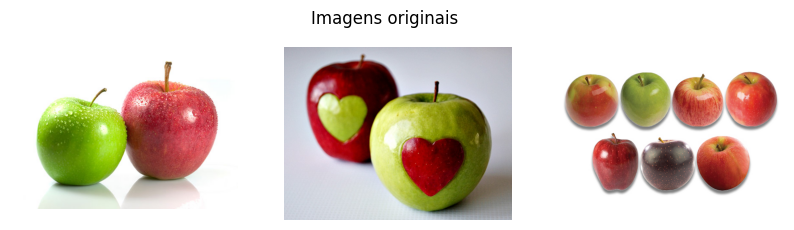

In [ ]:
img1 = cv2.cvtColor(cv2.imread("2apples.jpg"), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread("2or4objects.jpg"), cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(cv2.imread("7apples.jpg"), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,8))
fig.suptitle("Imagens originais", y=0.65)

ax[0].imshow(img1, vmin=0, vmax=255)
ax[0].axis("off")

ax[1].imshow(img2, vmin=0, vmax=255)
ax[1].axis("off")

ax[2].imshow(img3, vmin=0, vmax=255)
ax[2].axis("off")

In [ ]:
def spatial_feature_array(img):
    h, w, c = img.shape
    modified_arr = []
    for x in range(h):
        for y in range(w):
            r, g, b = np.rollaxis(img[x, y], -1)
            modified_arr.append([r, g, b, x, y])

    return np.array(modified_arr, dtype=np.int32)


def plot_3d(
    img, title, spatial_features=False, clusters=[2, 3], ticks=np.arange(0, 255, 50)
):
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle(title, y=0.8)

    # original image
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.imshow(img, vmin=0, vmax=255)
    ax1.set_title("Imagem Original")
    ax1.axis("off")

    ax3d = fig.add_subplot(2, 3, 4, projection="3d")
    r, g, b = np.rollaxis(img, -1)  # extract RGB values from the segmented image
    rgb_colors = (
        np.column_stack((r.flatten(), g.flatten(), b.flatten())) / 255.0
    )  # divided by 255 to norm
    ax3d.scatter(r, g, b, s=1, c=rgb_colors)
    ax3d.set_xlabel("R")
    ax3d.set_ylabel("G")
    ax3d.set_zlabel("B")
    ax3d.set_xticks(ticks)
    ax3d.set_yticks(ticks)
    ax3d.set_zticks(ticks)

    if not spatial_features:
        img_reshaped = img.reshape(-1, 3)
    else:
        img_reshaped = spatial_feature_array(img=img) * np.array(
            [1, 1, 1, 1 / img.shape[0], 1 / img.shape[1]]
        )  # scale x and y

    for i, cluster in enumerate(clusters, 1):
        kmeans = KMeans(n_clusters=cluster, random_state=0, n_init=10)
        kmeans.fit(img_reshaped)  # fit to compute values

        print(f"Centers: {kmeans.cluster_centers_.shape}")
        if spatial_features:
            kmeans.cluster_centers_ = np.delete(
                kmeans.cluster_centers_, [3, 4], axis=1
            )  # delete x and y (after fitting, is no longer important)
            print(
                f"Centers Shape after deletion of columns 3 and 4: {kmeans.cluster_centers_.shape}"
            )

        # map each pixel to its corresponding centroid
        print(
            f"Centroid Mapped Shape after deletion of columns 3 and 4: {kmeans.cluster_centers_[kmeans.labels_].shape}"
        )
        img_segmented = np.uint8(
            kmeans.cluster_centers_[kmeans.labels_].reshape(img.shape)
        )

        ax_img = fig.add_subplot(2, 3, i + 1)
        ax_img.imshow(img_segmented, vmin=0, vmax=255)
        ax_img.set_title(f"n_cluster={cluster}")
        ax_img.axis("off")

        ax3d = fig.add_subplot(2, 3, i + 4, projection="3d")
        r_seg, g_seg, b_seg = np.rollaxis(
            img_segmented, -1
        )  # extract RGB values from the segmented image
        rgb_colors = (
            np.column_stack((r_seg.flatten(), g_seg.flatten(), b_seg.flatten())) / 255.0
        )  # divided by 255 to norm
        ax3d.scatter(r, g, b, s=5, c=rgb_colors)
        ax3d.set_xlabel("R")
        ax3d.set_ylabel("G")
        ax3d.set_zlabel("B")
        ax3d.set_xticks(ticks)
        ax3d.set_yticks(ticks)
        ax3d.set_zticks(ticks)

    plt.subplots_adjust(wspace=0.4, hspace=-0.45)
    plt.show()


Centers: (2, 3)
Centroid Mapped Shape after deletion of columns 3 and 4: (371700, 3)
Centers: (3, 3)
Centroid Mapped Shape after deletion of columns 3 and 4: (371700, 3)


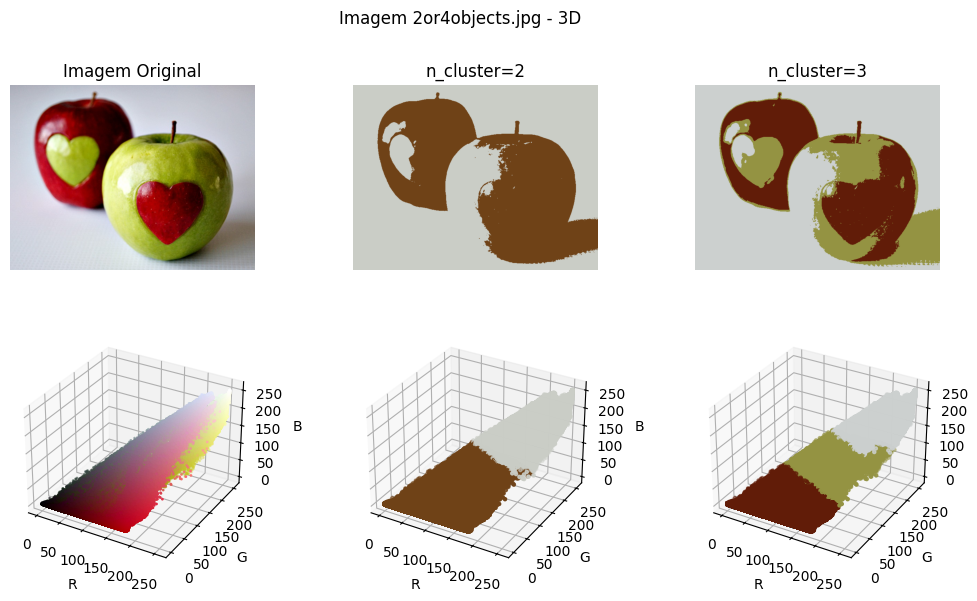

In [ ]:
# A
plot_3d(img2, "Imagem 2or4objects.jpg - 3D")

Centers: (2, 5)
Centers Shape after deletion of columns 3 and 4: (2, 3)
Centroid Mapped Shape after deletion of columns 3 and 4: (371700, 3)
Centers: (3, 5)
Centers Shape after deletion of columns 3 and 4: (3, 3)
Centroid Mapped Shape after deletion of columns 3 and 4: (371700, 3)


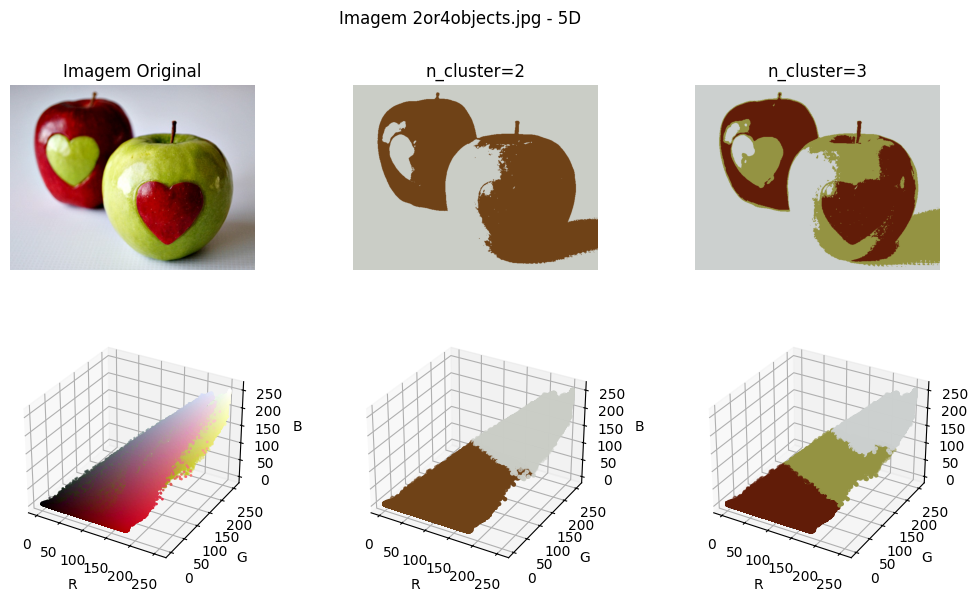

In [ ]:
# B
plot_3d(img2, "Imagem 2or4objects.jpg - 5D", True)

## Parte 2

Realizar a detecção de rosto para as imagens de rosto disponíveis no github da disciplina, implemente os seguintes métodos para detecção de rosto: <br>
1. Skin color thresholding: Escolha um intervalo de valores de pixel apropriado para a pele (use suas
habilidades de “pesquisa no Google”). Limite os valores de pixels com base neste intervalo para obter
regiões da pele. Responda a pergunta: para realizar esta operação, RGB é um bom espaço de cores ou
HSV é melhor?. Uma abordagem é apresentada em:
o https://arxiv.org/ftp/arxiv/papers/1708/1708.02694.pdf  <br>

2. Segmentação semeada (Seeded segmentation): Para isso, selecione manualmente um pixel da região
da face. Analise recursivamente a média dos pixels da vizinhança usando a intensidade média de
execução da pele, definindo uma tolerância apropriada. <br>

Dica: pesquise sobre “SeedPointSegmentation”
para encontrar abordagens.
Você também pode testar com mais imagens além do dataset fornecido. Recomendo usar o gerador de faces
que não existe disponíveis na internet. Além disso, vocês devem apresentar uma discussão sobre métricas de
avaliação para segmentação e quais poderiam ser usadas em segmentação sem abordagens de Deep Learning.

1. https://stanford.edu/~cpiech/cs221/handouts/kmeans.html

### Implementação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cv2
from google.colab.patches import cv2_imshow
from tqdm import tqdm

In [ ]:
class KMeans:
    def __init__(self, n_clusters=2, init="random", n_init=10, max_iter=100, converge_tol=0.0001):
        self.n_clusters = n_clusters
        self.init = init
        self.n_init = n_init
        self.max_iter = max_iter
        self.converge_tol = converge_tol
        self.centroids = None

    def euclidean_distance(a, b):
        return np.sqrt((b[1] - a[1]**2 + b[0] - a[0])**2)

    def calc_centroids(self, m, n):
        if self.init == "random":
            return np.array(
                [[np.random.randint(low=0, high=m), np.random.randint(low=0, high=n)] for _ in range(3)]
            )
        else:
            raise("Not Implemented")

    def fit(self, X):
        try:
            m, n = X.shape
        except Exception as e: # ponto problematico
            raise(f"Shape related exception: {e}")

        self.centroids = self.calc_centroids(m, n)
        converged = False
        iter_counter = 0

        while not converged or iter_counter < self.max_iter:
            clusters = []

            for i in range(m):
                point = X[i] # ponto problematico
                closest_index = 0
                print(point)
                return
                min_distance = self.euclidean_distance(point, self.centroids[0]) # ponto problematico

                for j in range(1, self.n_clusters):
                    d = self.euclidean_distance(point, self.centroids[j])
                    if d < min_distance:
                        min_distance = d
                        closest_index = j
                clusters[closest_index].append(point)

            new_centroids = self.calc_centroids(m, n)
            if new_centroids == self.centroids:
                converged = True # redundância
                return clusters
            else:
                self.centroids = new_centroids
                iter_counter++


In [ ]:
kmeans = KMeans()
kmeans.fit(img1)

TypeError: exceptions must derive from BaseException